
# 00 — Quickstart: SDGFT-ML-Toolkit

This notebook demonstrates the core workflow in under 5 minutes:

1. **Load** the GNN ensemble predictor
2. **Predict** all 37 observables at the axiom point
3. **Compare** predictions to 22 experimental measurements
4. **Query** the Oracle Database for best-fit parameter regions

**Prerequisites:** `pip install -e .` from the project root.

> **Oracle Database DOI:** [10.5281/zenodo.18863347](https://doi.org/10.5281/zenodo.18863347)


In [ ]:
# Install in Colab / fresh environment (skip if already installed)
# !pip install -e /path/to/sdgft-ml-toolkit

## 1. Load the GNN Ensemble Predictor

The `SDGFTPredictor` loads 5 trained GATv2 ensemble members (~1.3M params each)
and provides a simple prediction interface.

In [1]:
from sdgft_ml.inference import SDGFTPredictor

predictor = SDGFTPredictor()   # auto-detects GPU, loads all 5 members
print(predictor)
print(f"\nModel info: {predictor.info}")

/home/david/Coding/sdgft/sdgft-ml-toolkit/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SDGFTPredictor(members=5, obs=37, device='cuda')

Model info: {'n_ensemble_members': 5, 'n_observables': 37, 'n_model_parameters': 845825, 'architecture': 'GATv2Conv', 'hidden_dim': 128, 'n_heads': 8, 'n_layers': 6, 'device': 'cuda', 'checkpoint_dir': '/home/david/Coding/sdgft/sdgft-ml-toolkit/checkpoints/ensemble'}


## 2. Predict at the Axiom Point

The SDGFT axiom fixes Δ = 5/24 ≈ 0.2083, δ_g = 1/24 ≈ 0.04167, φ = golden ratio.
One call returns all 37 observables.

In [2]:
# Simple prediction — ensemble mean
result = predictor.predict()   # defaults to axiom point

print("Key predictions at the axiom point:")
print(f"  Higgs mass:          {result['higgs_mass']:.2f} GeV")
print(f"  sin²θ_W:            {result['sin2_theta_w']:.5f}")
print(f"  α_s(M_Z):           {result['alpha_s']:.4f}")
print(f"  n_s:                 {result['n_s']:.4f}")
print(f"  Ω_m:                {result['omega_m']:.4f}")
print(f"  Ω_Λ:                {result['omega_de']:.4f}")
print(f"  N_gen:              {result['n_generations']:.3f}")

Key predictions at the axiom point:
  Higgs mass:          124.94 GeV
  sin²θ_W:            0.23121
  α_s(M_Z):           0.1178
  n_s:                 0.9670
  Ω_m:                0.3103
  Ω_Λ:                0.6897
  N_gen:              3.001


In [3]:
# Prediction with ensemble uncertainty (mean ± std)
result_unc = predictor.predict_with_uncertainty()

for name in ["higgs_mass", "sin2_theta_w", "n_s", "omega_m", "r_tensor"]:
    r = result_unc[name]
    print(f"  {name:<22s}  {r['mean']:>12.6g}  ± {r['std']:>10.6g}")

  higgs_mass                   124.944  ±  0.0124534
  sin2_theta_w                0.231215  ± 3.22968e-05
  n_s                         0.967049  ± 1.62659e-05
  omega_m                     0.310277  ± 0.00028463
  r_tensor                   0.0130069  ± 9.39454e-05


## 3. Compare to Experimental Data

The validation module compares theory predictions against 22 precision
measurements from PDG 2024, Planck 2018, NuFIT 5.3, and BICEP/Keck.

In [4]:
from sdgft_ml.validation import validate_at_axiom, scorecard, chi_squared

# Run validation at the axiom point
results = validate_at_axiom()

# Print the full scorecard
scorecard(results)


  SDGFT Physics Scorecard

  ── COSMOLOGY ──
  Observable                         Theory   Experiment Pull (σ)     Status
  --------------------------------------------------------------------------
  S_8                               0.78823        0.832    -3.37          ✗
  w_DE (equation of state)        -0.932255        -1.03    +3.26          ✗
  Ω_m                               0.31033       0.3153    -0.68          ✓
  Ω_Λ                               0.68967       0.6847    +0.68          ✓
  η_B (baryon asymmetry)        6.26844e-10    6.143e-10    +0.66          ✓
  Ω_c                              0.260417        0.265    -0.65          ✓
  Ω_b h² → Ω_b                    0.0499132       0.0493    +0.31          ✓

  ── INFLATION ──
  Observable                         Theory   Experiment Pull (σ)     Status
  --------------------------------------------------------------------------
  n_s (scalar spectral index)      0.967067       0.9649    +0.52          ✓
  r (tensor

In [5]:
# χ² summary
chi2 = chi_squared(results)
print(f"\nχ² = {chi2['chi2']:.2f}  (N_dof = {chi2['ndof']}, χ²/dof = {chi2['chi2_per_dof']:.2f})")
print(f"p-value = {chi2['p_value']:.4f}")

print("\nPer-category breakdown:")
for cat, info in chi2['per_category'].items():
    print(f"  {cat:<14s}  χ²={info['chi2']:.2f}  dof={info['ndof']}  χ²/dof={info['chi2_per_dof']:.2f}")


χ² = 32.54  (N_dof = 22, χ²/dof = 1.48)
p-value = 0.0686

Per-category breakdown:
  cosmology       χ²=23.84  dof=7  χ²/dof=3.41
  inflation       χ²=0.40  dof=2  χ²/dof=0.20
  particle        χ²=8.31  dof=13  χ²/dof=0.64


## 4. Query the Oracle Database

The Oracle DB contains 61.7M+ pre-computed parameter points with χ² scores.
It enables instant exploration of the parameter landscape without re-running the GNN.

In [6]:
from sdgft_ml.inference import OracleDB

db = OracleDB()   # lazy-loads on first access
print(db.summary())

SDGFT Oracle Database
  Rows:       61,701,488
  Columns:    44
  Δ range:    [0.204400, 0.216900]
  δ_g range:  [0.040000, 0.043000]
  Gold Std:   35,021,095
  Best χ²:    16.9696
  File:       /home/david/Coding/sdgft/sdgft-ml-toolkit/data/oracle_db.parquet
  Size:       3.41 GB


In [7]:
# Top 10 best-fit parameter points
top10 = db.best_fit(10)
top10[["delta", "delta_g", "total_chi2", "chi2_per_dof", "higgs_mass", "n_s", "omega_m"]]

,delta,delta_g,total_chi2,chi2_per_dof,higgs_mass,n_s,omega_m
30645391,0.210633,0.041865,16.969616,0.808077,125.630089,0.966434,0.316603
30655371,0.210635,0.041859,16.969616,0.808077,125.630684,0.966434,0.316609
30655381,0.210635,0.041862,16.969616,0.808077,125.630684,0.966434,0.316609
30655383,0.210635,0.041863,16.969618,0.808077,125.630684,0.966434,0.316609
30655368,0.210635,0.041858,16.969620,0.808077,125.630684,0.966435,0.316609
30655379,0.210635,0.041861,16.969620,0.808077,125.630684,0.966434,0.316609
30655380,0.210635,0.041862,16.969622,0.808077,125.630684,0.966434,0.316609
30645389,0.210633,0.041864,16.969624,0.808077,125.630089,0.966434,0.316603
30645390,0.210633,0.041865,16.969624,0.808077,125.630089,0.966434,0.316603
30655362,0.210635,0.041856,16.969624,0.808077,125.630684,0.966435,0.316609


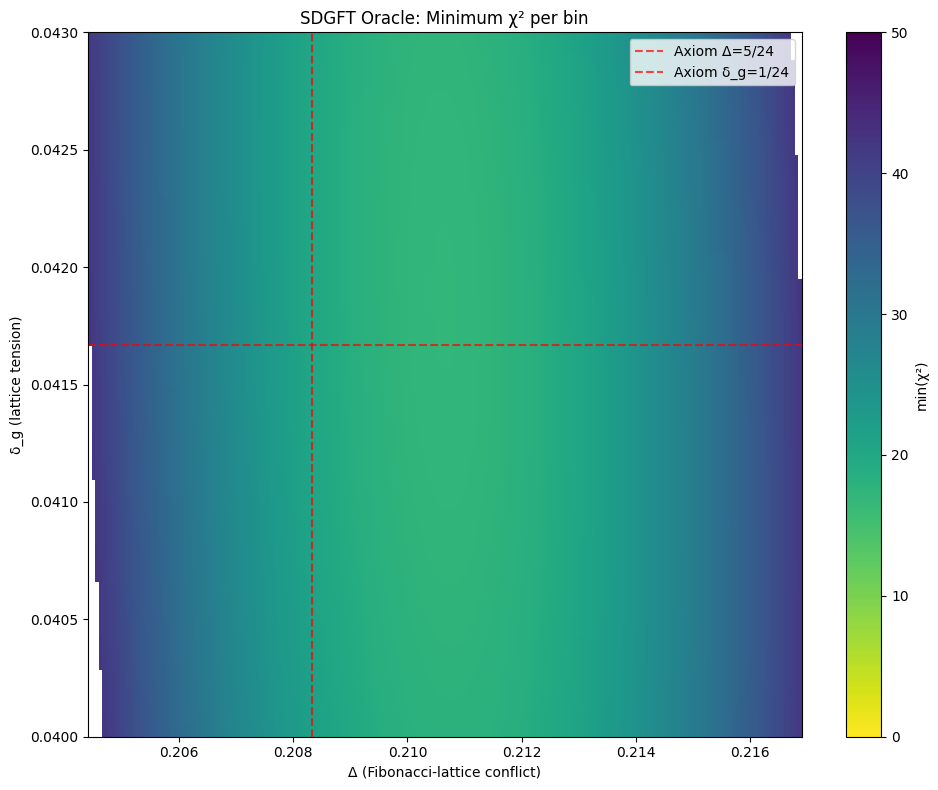

In [8]:
# Quick heatmap of the χ² landscape
import matplotlib.pyplot as plt
import numpy as np

grid, d_edges, dg_edges = db.chi2_heatmap(bins=200)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    grid.T, origin="lower", aspect="auto",
    extent=[d_edges[0], d_edges[-1], dg_edges[0], dg_edges[-1]],
    cmap="viridis_r", vmin=0, vmax=50,
)
ax.set_xlabel("Δ (Fibonacci-lattice conflict)")
ax.set_ylabel("δ_g (lattice tension)")
ax.set_title("SDGFT Oracle: Minimum χ² per bin")
ax.axvline(5/24, color='r', ls='--', alpha=0.7, label=f'Axiom Δ=5/24')
ax.axhline(1/24, color='r', ls='--', alpha=0.7, label=f'Axiom δ_g=1/24')
ax.legend()
plt.colorbar(im, label="min(χ²)")
plt.tight_layout()
plt.show()

---

## Next Steps

- **[01 Oracle Queries](01_oracle_queries.ipynb)** — Advanced filtering, DuckDB integration, export
- **[02 Parameter Landscape](02_parameter_landscape.ipynb)** — Sensitivity maps, correlation analysis
- **[03 Experimental Validation](03_experimental_validation.ipynb)** — Full 22-observable scorecard, pull distributions
- **[04 Predictions & Frontier](04_predictions_frontier.ipynb)** — W-boson mass, muon g-2, gravitational waves
- **[05 Inverse Problem](05_inverse_problem.ipynb)** — CVAE parameter recovery from observations